# Блок 2. RFM-сегментация клиентской базы

**Вопрос:** на какие сегменты делятся клиенты H&M и какие приносят больше денег?

**Данные:** витрина hm.rfm_mart (1 строка = 1 клиент)
**Период:** последние 12 месяцев (2019-10-01 .. 2020-09-22)
**Метод:** RFM по квинтилям, сегментация по RF-матрице

## Что проверяем
- Распределение клиентов по сегментам
- Вклад сегментов в выручку (правило Парето)
- Связь сегментов с демографией и членством в клубе

In [ ]:
import clickhouse_connect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

client = clickhouse_connect.get_client(
    host='localhost', port=8123,
    username='analyst', password='analyst', database='hm'
)

def q(sql: str) -> pd.DataFrame:
    return client.query_df(sql)

rfm = q("SELECT * FROM hm.rfm_mart")
print(f"Клиентов в витрине: {len(rfm):,}")
rfm.head()

Клиентов в витрине: 984,727


,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rf_score,segment
0,b'00000dbacae5abe5e23885899a1fa44253a17956c6d1...,17,10,0.240695,5,3,3,8,Loyal
1,b'0000423b00ade91418cceaf3b26c6af3dd342b51fd05...,76,35,0.887542,3,5,5,8,Loyal
2,b'000058a12d5b43e67d225668fa1f8d618c13dc232df0...,7,14,0.559085,5,4,4,9,Champions
3,b'00006413d8573cd20ed7128e53b7b13819fe5cfc2d80...,41,9,0.359593,4,3,4,7,Loyal
4,b'000064249685c11552da43ef22a5030f35a147f723d5...,356,3,0.101644,1,2,2,3,Lost


In [2]:
# Смотрим на распределения R, F, M
rfm[['recency', 'frequency', 'monetary']].describe()

,recency,frequency,monetary
count,984727.000000,984727.000000,984727.000000
mean,114.054742,14.667265,0.411563
std,99.894697,21.397064,0.656483
min,0.000000,1.000000,0.000763
25%,30.000000,3.000000,0.081322
50%,84.000000,7.000000,0.198169
75%,178.000000,18.000000,0.474271
max,357.000000,1004.000000,34.954610


**Наблюдения по распределению RFM:**
- Frequency и Monetary сильно правоскошены: mean заметно выше median
  (F: mean 14.7 vs median 7; M: mean 0.41 vs median 0.20).
  Небольшая группа сверх-активных клиентов тянет среднее вверх.
- Аномалия: max frequency = 1004 покупки/год (~3/день) — вероятно
  оптовик или корпоративный аккаунт, не типичный розничный клиент.
- Recency max = 357 дней ≈ размер окна (год). Все клиенты витрины
  покупали хотя бы раз за период — sanity-check пройден.
- Медианный клиент: покупал 7 раз за год, последняя покупка 84 дня назад.

**Проверим аномалии частоты:**

In [ ]:
outliers = q("""
SELECT
    multiIf(
        frequency >= 500, '500+',
        frequency >= 200, '200-499',
        frequency >= 100, '100-199',
        frequency >= 50,  '50-99',
        '<50'
    ) AS freq_bucket,
    count() AS customers
FROM hm.rfm_mart
GROUP BY freq_bucket
ORDER BY customers DESC
""")
display(outliers)

,freq_bucket,customers
0,<50,931454
1,50-99,43020
2,100-199,9102
3,200-499,1119
4,500+,32


Клиенты с frequency 500+ : 32 чел, 200-499 : ~1100 чел (вместе <0.15% базы).
Это устойчивая микрогруппа сверх-активных клиентов (вероятно перекупщики
или корпоративные аккаунты), а не единичная ошибка данных.
- Для RFM/дашборда: не трогаем, попадают в Champions корректно.
- Для churn-модели (Блок 5): обработать хвост frequency (log/winsorize).

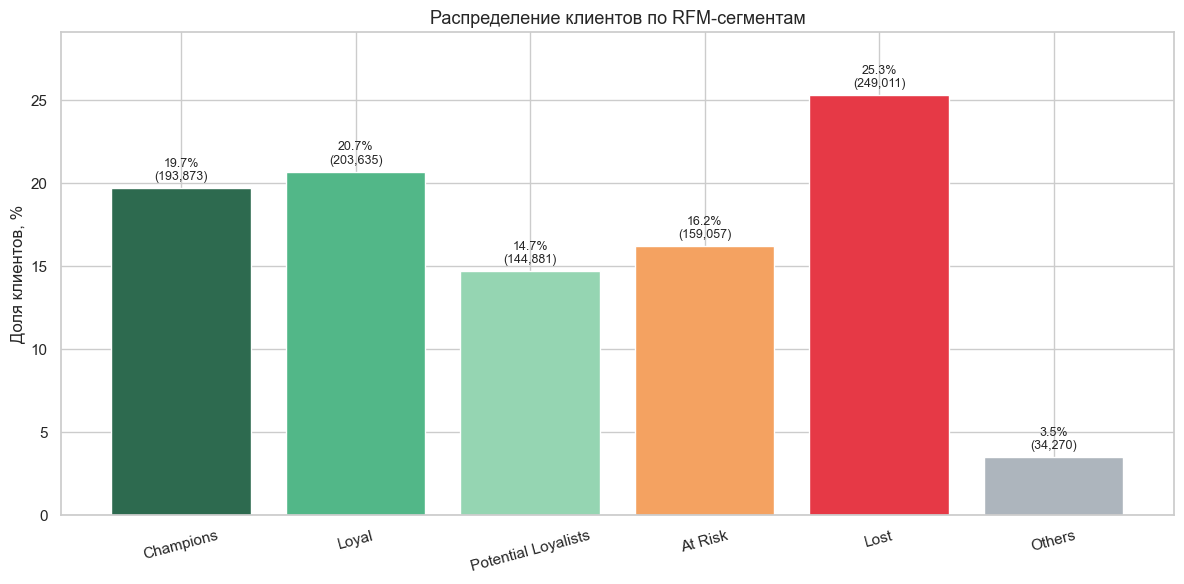

In [4]:
seg_dist = q("""
SELECT
    segment,
    count() AS customers,
    round(count() * 100.0 / sum(count()) OVER (), 1) AS pct
FROM hm.rfm_mart
GROUP BY segment
ORDER BY customers DESC
""")

# Порядок сегментов от "лучших" к "худшим" для логичной визуализации
order = ['Champions', 'Loyal', 'Potential Loyalists', 'At Risk', 'Lost', 'Others']
seg_dist['segment'] = pd.Categorical(seg_dist['segment'], categories=order, ordered=True)
seg_dist = seg_dist.sort_values('segment')

colors = {
    'Champions': '#2d6a4f', 'Loyal': '#52b788',
    'Potential Loyalists': '#95d5b2', 'At Risk': '#f4a261',
    'Lost': '#e63946', 'Others': '#adb5bd'
}

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(seg_dist['segment'], seg_dist['pct'],
              color=[colors[s] for s in seg_dist['segment']], edgecolor='white')

for bar, pct, cust in zip(bars, seg_dist['pct'], seg_dist['customers']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{pct}%\n({cust:,})', ha='center', va='bottom', fontsize=9)

ax.set_title('Распределение клиентов по RFM-сегментам', fontsize=13)
ax.set_ylabel('Доля клиентов, %')
ax.set_ylim(0, max(seg_dist['pct']) * 1.15)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Вывод по распределению сегментов:**
- Размеры сегментов 3.5%–25.3%. Различие связано с тем, сколько ячеек
  RF-матрицы покрывает каждый сегмент, и с реальным распределением
  клиентов H&M по этим ячейкам.
- Lost — крупнейший сегмент (25.3%). Для годового окна это нормальный
  уровень оттока в fashion-ритейле.
- Активное ядро (Champions + Loyal) = 40.4% — здоровая база.

Решение: маркетинговый фокус — на At Risk (16.2%), которых ещё можно
удержать. Lost (25%) — низкоприоритетны для дорогих кампаний
(низкая конверсия win-back).

In [5]:
pareto = q("""
SELECT
    segment,
    count()                                          AS customers,
    round(sum(monetary), 0)                          AS revenue,
    round(sum(monetary) * 100.0 / sum(sum(monetary)) OVER (), 1) AS revenue_pct,
    round(count() * 100.0 / sum(count()) OVER (), 1) AS customers_pct,
    round(avg(monetary), 3)                          AS avg_revenue_per_customer
FROM hm.rfm_mart
GROUP BY segment
ORDER BY revenue DESC
""")
display(pareto)

,segment,customers,revenue,revenue_pct,customers_pct,avg_revenue_per_customer
0,Champions,193873,223271.0,55.1,19.7,1.152
1,Loyal,203635,88700.0,21.9,20.7,0.436
2,At Risk,159057,55026.0,13.6,16.2,0.346
3,Lost,249011,19223.0,4.7,25.3,0.077
4,Potential Loyalists,144881,11887.0,2.9,14.7,0.082
5,Others,34270,7170.0,1.8,3.5,0.209


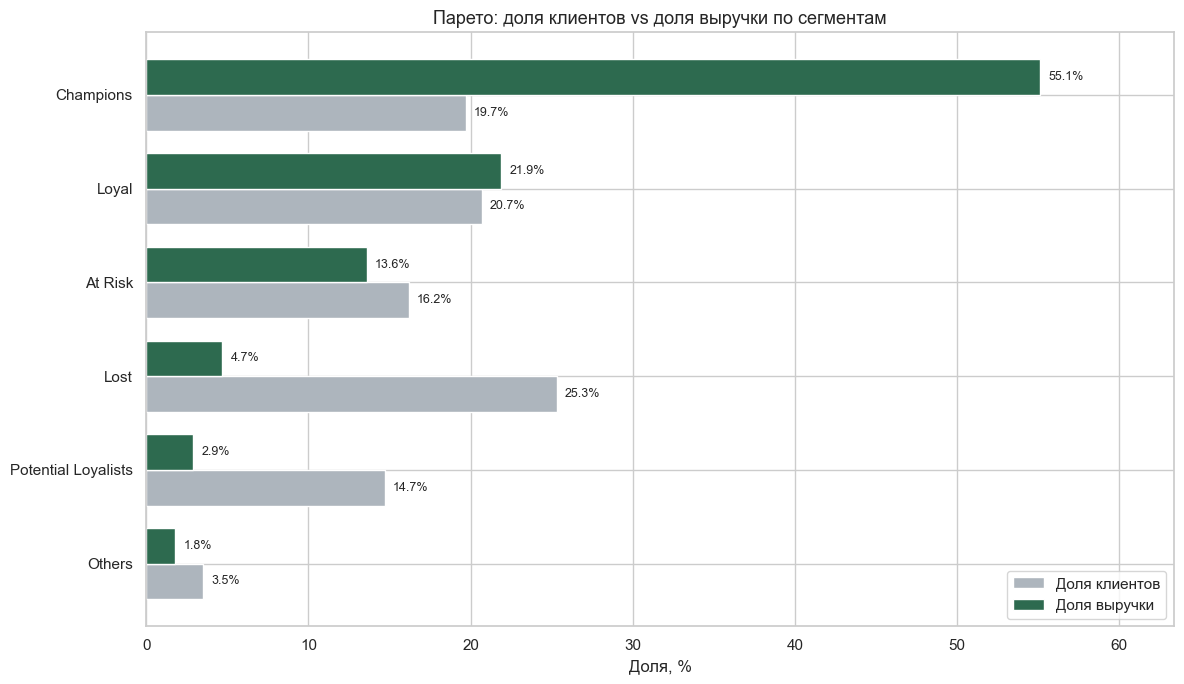

In [7]:
# Сортируем по убыванию выручки и фиксируем порядок
pareto_sorted = pareto.sort_values('revenue_pct', ascending=True)  # ascending для barh снизу вверх

y = np.arange(len(pareto_sorted))
height = 0.38

fig, ax = plt.subplots(figsize=(12, 7))

bars_cust = ax.barh(y - height/2, pareto_sorted['customers_pct'], height,
                    label='Доля клиентов', color='#adb5bd', edgecolor='white')
bars_rev = ax.barh(y + height/2, pareto_sorted['revenue_pct'], height,
                   label='Доля выручки', color='#2d6a4f', edgecolor='white')

# Подписи значений
for bars in [bars_cust, bars_rev]:
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.5, bar.get_y() + bar.get_height()/2,
                f'{w:.1f}%', va='center', fontsize=9)

ax.set_yticks(y)
ax.set_yticklabels(pareto_sorted['segment'])
ax.set_xlabel('Доля, %')
ax.set_title('Парето: доля клиентов vs доля выручки по сегментам', fontsize=13)
ax.legend(loc='lower right')
ax.set_xlim(0, max(pareto_sorted['revenue_pct']) * 1.15)
plt.tight_layout()
plt.show()

**Вклад сегментов в выручку (правило Парето):**

| Сегмент | Клиентов | Выручка | Ср. выручка/клиент |
|---|---|---|---|
| Champions | 19.7% | 55.1% | 1.15 |
| Loyal | 20.7% | 21.9% | 0.44 |
| At Risk | 16.2% | 13.6% | 0.35 |
| Lost | 25.3% | 4.7% | 0.08 |
| Potential Loyalists | 14.7% | 2.9% | 0.08 |

- **Champions: 19.7% клиентов дают 55.1% выручки** — каждый пятый клиент
  приносит больше половины денег.
- Топ-2 сегмента (Champions + Loyal): 40.4% клиентов → 77% выручки.
- Lost: 25.3% базы, но лишь 4.7% выручки — низкая отдача.
- At Risk по средней выручке на клиента (0.35) близок к Loyal (0.44):
  это уходящие, но всё ещё ценные клиенты.

Решение: удержание сфокусировать на At Risk — высокая ценность
при риске оттока. Champions защищать (VIP, ранний доступ).
Lost не приоритизировать в платных кампаниях.

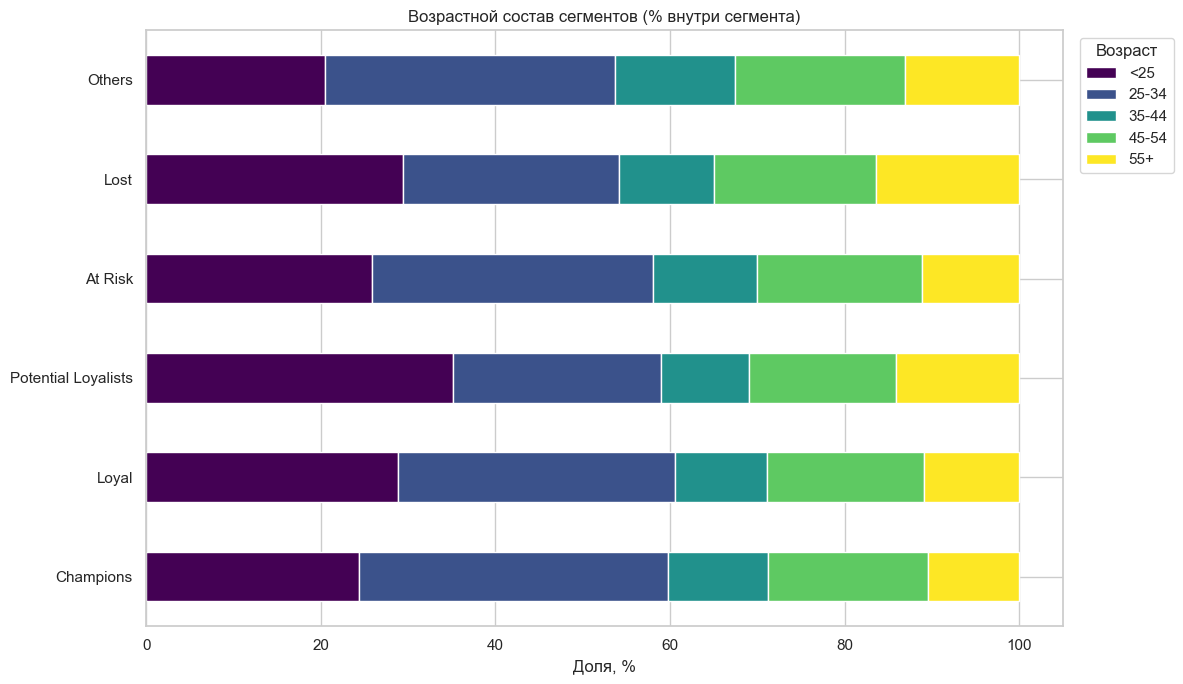

age_group,<25,25-34,35-44,45-54,55+
segment,,,,,
Champions,24.4,35.4,11.4,18.3,10.4
Loyal,28.8,31.7,10.6,18.0,10.9
Potential Loyalists,35.1,23.9,10.0,16.8,14.1
At Risk,25.9,32.2,11.9,18.9,11.2
Lost,29.4,24.7,10.9,18.6,16.4
Others,20.5,33.2,13.8,19.5,13.1


In [8]:
seg_age = q("""
SELECT
    r.segment,
    multiIf(
        c.age < 25, '<25',
        c.age < 35, '25-34',
        c.age < 45, '35-44',
        c.age < 55, '45-54',
        '55+'
    ) AS age_group,
    count() AS customers
FROM hm.rfm_mart r
INNER JOIN hm.customers c ON r.customer_id = c.customer_id
WHERE c.age IS NOT NULL
GROUP BY r.segment, age_group
""")

# Доля возрастных групп внутри каждого сегмента (нормируем по сегменту)
pivot_age = seg_age.pivot(index='segment', columns='age_group', values='customers')
pivot_age_pct = pivot_age.div(pivot_age.sum(axis=1), axis=0) * 100

order_seg = ['Champions', 'Loyal', 'Potential Loyalists', 'At Risk', 'Lost', 'Others']
order_age = ['<25', '25-34', '35-44', '45-54', '55+']
pivot_age_pct = pivot_age_pct.reindex(order_seg)[order_age]

# Stacked bar
pivot_age_pct.plot(kind='barh', stacked=True, figsize=(12, 7),
                   colormap='viridis', edgecolor='white')
plt.title('Возрастной состав сегментов (% внутри сегмента)')
plt.xlabel('Доля, %')
plt.ylabel('')
plt.legend(title='Возраст', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

display(pivot_age_pct.round(1))

**Демография по сегментам:**
- Возрастной профиль сегментов почти одинаков (доля <25 лет: 24-29%
  во всех ключевых сегментах). Лояльность не зависит от возраста.
- Исключение: Potential Loyalists содержат больше молодёжи <25 (35%) —
  это недавно пришедшие клиенты без накопленной истории.
→ Решение: удержание таргетировать по поведению (RFM), не по возрасту.

In [9]:
seg_club = q("""
SELECT
    r.segment,
    if(c.club_member_status = '', 'Unknown', c.club_member_status) AS club_status,
    count() AS customers
FROM hm.rfm_mart r
INNER JOIN hm.customers c ON r.customer_id = c.customer_id
GROUP BY r.segment, club_status
""")

pivot_club = seg_club.pivot(index='segment', columns='club_status', values='customers').fillna(0)
pivot_club_pct = pivot_club.div(pivot_club.sum(axis=1), axis=0) * 100
pivot_club_pct = pivot_club_pct.reindex(order_seg)

display(pivot_club_pct.round(1))

club_status,ACTIVE,LEFT CLUB,PRE-CREATE,Unknown
segment,,,,
Champions,99.3,0.0,0.5,0.1
Loyal,98.3,0.0,1.6,0.1
Potential Loyalists,94.6,0.0,5.2,0.2
At Risk,96.0,0.0,3.8,0.2
Lost,91.6,0.0,7.8,0.6
Others,94.2,0.1,5.3,0.5


**Членство в клубе по сегментам:**
- Чёткий градиент: чем выше ценность сегмента, тем выше доля ACTIVE.
  Champions — 99.3% ACTIVE, Lost — 91.6%.
- PRE-CREATE (не активировал членство) растёт к «худшим» сегментам:
  Champions 0.5% → Lost 7.8% (×15).
→ Статус PRE-CREATE — ранний маркер риска оттока.
  Кандидат в сильные предикторы churn-модели (Блок 5).

## Итоги Блока 2 (RFM-сегментация)

1. База разбита на 6 сегментов по поведению (Recency + Frequency).
2. Сильная концентрация выручки: Champions (19.7% клиентов) дают 55.1%
   выручки; топ-2 сегмента — 77% выручки при 40% клиентов.
3. At Risk (16.2%) — приоритет удержания: высокая ценность
   (ср. выручка близка к Loyal) при риске ухода.
4. Lost (25.3% базы) дают лишь 4.7% выручки — низкий приоритет.
5. Лояльность не связана с возрастом, но связана с активацией клуба.

Связь с другими блоками:
- At Risk → целевой сегмент для A/B-теста (Блок 4)
- RFM-метрики и сегмент → фичи для churn-модели (Блок 5)
- club_member_status → кандидат в сильные предикторы оттока